In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr
import re
from pprint import pprint
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

Import Data

In [3]:
df = pd.read_csv("../../data/processed/CA_Fara_500_2019.csv")

Info

In [4]:
df.describe()

,GEOID,TotalPopulation,ACCESS2_CrudePrev,ARTHRITIS_CrudePrev,BINGE_CrudePrev,BPHIGH_CrudePrev,BPMED_CrudePrev,CANCER_CrudePrev,CASTHMA_CrudePrev,CERVICAL_CrudePrev,CHD_CrudePrev,CHECKUP_CrudePrev,CHOLSCREEN_CrudePrev,COLON_SCREEN_CrudePrev,COPD_CrudePrev,COREM_CrudePrev,COREW_CrudePrev,CSMOKING_CrudePrev,DENTAL_CrudePrev,DEPRESSION_CrudePrev,DIABETES_CrudePrev,GHLTH_CrudePrev,HIGHCHOL_CrudePrev,KIDNEY_CrudePrev,LPA_CrudePrev,MAMMOUSE_CrudePrev,MHLTH_CrudePrev,OBESITY_CrudePrev,PHLTH_CrudePrev,SLEEP_CrudePrev,STROKE_CrudePrev,TEETHLOST_CrudePrev,Urban,Pop2010,OHU2010,LILATracts_1And10,LILATracts_halfAnd10,LILATracts_1And20,LILATracts_Vehicle,HUNVFlag,LowIncomeTracts,PovertyRate,MedianFamilyIncome,LA1and10,LAhalfand10,LA1and20,LATracts_half,LATracts1,LATracts10,LATracts20,LATractsVehicle_20,LAPOP1_10,LAPOP05_10,LAPOP1_20,LALOWI1_10,LALOWI05_10,LALOWI1_20,TractLOWI,TotalPop,UninsuredPop,MedHouseInc
count,8.004000e+03,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,8002.000000,8004.000000,8004.000000,8004.000000,8003.000000,8004.000000,7993.000000,7979.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,7995.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,7997.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,7937.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,7963.000000
mean,6.054922e+09,4654.074088,16.017716,19.480210,17.631234,27.052024,67.144140,5.738981,8.674025,82.138178,4.904323,70.305760,85.670915,65.030289,5.140492,29.996309,29.752563,12.737869,63.718816,16.887294,9.878336,19.364918,29.232034,2.816642,23.809195,77.934984,13.410457,26.968766,12.170152,34.612844,2.877186,11.866325,0.916667,4654.074088,1571.276862,0.066842,0.264368,0.061969,0.062969,0.094328,0.432034,14.574325,88380.870606,0.244253,0.695902,0.234133,0.683533,0.231884,0.012369,0.002249,0.096327,618.569090,2083.846577,599.732134,150.539730,596.667791,143.461144,1561.220640,4907.323963,182.607696,81511.300766
std,2.654240e+07,1955.764393,8.569052,4.657959,2.650999,4.812394,6.376746,1.929911,1.284996,4.408860,1.522260,3.825505,4.252023,7.667068,1.667168,6.085794,5.337051,3.680272,11.098420,2.565622,2.680269,7.543501,4.088139,0.693824,7.208410,2.028883,3.042514,5.873023,3.330223,4.044929,0.844684,5.998150,0.276403,1955.764393,671.961007,0.249763,0.441024,0.241114,0.242921,0.292303,0.495390,10.912721,44735.484073,0.429670,0.460053,0.423482,0.465126,0.422062,0.110532,0.047372,0.295057,1385.984127,2079.575521,1376.994123,417.025812,757.719009,410.778015,1141.117173,2253.866377,139.208654,39376.181964
min,6.001400e+09,56.000000,3.500000,2.500000,4.800000,5.700000,10.800000,0.600000,4.900000,46.100000,0.500000,53.100000,59.700000,36.500000,1.000000,13.400000,15.600000,3.200000,20.600000,8.000000,0.900000,5.700000,7.400000,0.600000,10.500000,68.700000,5.500000,11.900000,4.100000,20.200000,0.300000,2.800000,0.000000,56.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2499.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7461.000000
25%,6.037263e+09,3369.000000,9.200000,16.300000,16.200000,24.200000,63.800000,4.300000,7.700000,79.700000,4.000000,67.800000,83.100000,59.700000,4.000000,25.500000,25.800000,10.000000,55.800000,15.300000,8.075000,13.400000,26.900000,2.400000,18.000000,76.500000,11.100000,22.600000,9.700000,31.700000,2.400000,7.200000,1.000000,3369.000000,1110.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.500000,54281.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,200.750000,0.000000,0.000000,47.000000,0.000000,

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8004 entries, 0 to 8003
Data columns (total 93 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CountyName              8004 non-null   object 
 1   GEOID                   8004 non-null   int64  
 2   TotalPopulation         8004 non-null   int64  
 3   ACCESS2_CrudePrev       8004 non-null   float64
 4   ACCESS2_Crude95CI       8004 non-null   object 
 5   ARTHRITIS_CrudePrev     8004 non-null   float64
 6   ARTHRITIS_Crude95CI     8004 non-null   object 
 7   BINGE_CrudePrev         8004 non-null   float64
 8   BINGE_Crude95CI         8004 non-null   object 
 9   BPHIGH_CrudePrev        8004 non-null   float64
 10  BPHIGH_Crude95CI        8004 non-null   object 
 11  BPMED_CrudePrev         8004 non-null   float64
 12  BPMED_Crude95CI         8004 non-null   object 
 13  CANCER_CrudePrev        8004 non-null   float64
 14  CANCER_Crude95CI        8004 non-null   

Population Weighting Function

In [6]:
def pop_weight(df: pd.DataFrame, col: str): 
    result_name = f"{col}_weighted"
    
    weighted = df.copy()
    weighted["weighted_val"] = weighted[col] * weighted["TotalPopulation"]
    grouped = weighted.groupby("CountyName").agg(
        total_weighted_val = ('weighted_val', 'sum'),
        total_weight = ('TotalPopulation', 'sum')
    )
    
    grouped[result_name] = grouped['total_weighted_val'] / grouped['total_weight']
    return grouped[[result_name]]

Check difference between population weighting and mean

ACCESS2_CrudePrev MSE: 0.3711547051812241
ARTHRITIS_CrudePrev MSE: 0.4387459304198873
BINGE_CrudePrev MSE: 0.09935125942630409
BPHIGH_CrudePrev MSE: 0.3668226330366824
BPMED_CrudePrev MSE: 0.6984614911075142
CANCER_CrudePrev MSE: 0.057035172199437
CASTHMA_CrudePrev MSE: 0.008001469751966656
CERVICAL_CrudePrev MSE: 0.09435254779712636
CHD_CrudePrev MSE: 0.04791783757510405
CHECKUP_CrudePrev MSE: 0.22532633689804976
CHOLSCREEN_CrudePrev MSE: 0.1949123452709853
COLON_SCREEN_CrudePrev MSE: 0.37353758893363453
COPD_CrudePrev MSE: 0.05029668161744705
COREM_CrudePrev MSE: 0.15573199085035822
COREW_CrudePrev MSE: 0.34599270953960437
CSMOKING_CrudePrev MSE: 0.09293356427794278
DENTAL_CrudePrev MSE: 0.6498298166086173
DEPRESSION_CrudePrev MSE: 0.03175589610740258
DIABETES_CrudePrev MSE: 0.06226827077992058
GHLTH_CrudePrev MSE: 0.22617240589928286
HIGHCHOL_CrudePrev MSE: 0.2779407982315096
KIDNEY_CrudePrev MSE: 0.006450679434722131
LPA_CrudePrev MSE: 0.18983512193651092
MAMMOUSE_CrudePrev MSE: 0.

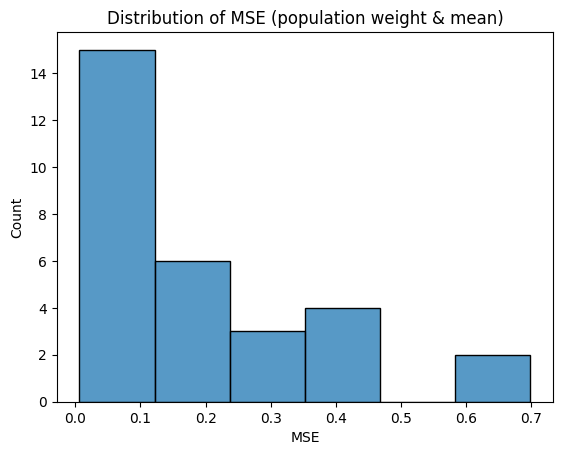

In [7]:
mses = []
for i in df.columns:
    if re.match(string=i, pattern=r'\S*(Prev)$'):
        pop_weighting = pop_weight(df, i)[f"{i}_weighted"]
        grouped = df.groupby("CountyName").agg({i: "mean"})[i]
        mse = ((grouped - pop_weighting) ** 2).mean()
        mses.append(mse)
        print(f"{i} MSE: {mse}")

ax = sns.histplot(data=mses)
ax.set(xlabel="MSE", ylabel="Count", title="Distribution of MSE (population weight & mean)")
plt.show()

DF Columns

In [8]:
pprint(df.columns)

Index(['CountyName', 'GEOID', 'TotalPopulation', 'ACCESS2_CrudePrev',
       'ACCESS2_Crude95CI', 'ARTHRITIS_CrudePrev', 'ARTHRITIS_Crude95CI',
       'BINGE_CrudePrev', 'BINGE_Crude95CI', 'BPHIGH_CrudePrev',
       'BPHIGH_Crude95CI', 'BPMED_CrudePrev', 'BPMED_Crude95CI',
       'CANCER_CrudePrev', 'CANCER_Crude95CI', 'CASTHMA_CrudePrev',
       'CASTHMA_Crude95CI', 'CERVICAL_CrudePrev', 'CERVICAL_Crude95CI',
       'CHD_CrudePrev', 'CHD_Crude95CI', 'CHECKUP_CrudePrev',
       'CHECKUP_Crude95CI', 'CHOLSCREEN_CrudePrev', 'CHOLSCREEN_Crude95CI',
       'COLON_SCREEN_CrudePrev', 'COLON_SCREEN_Crude95CI', 'COPD_CrudePrev',
       'COPD_Crude95CI', 'COREM_CrudePrev', 'COREM_Crude95CI',
       'COREW_CrudePrev', 'COREW_Crude95CI', 'CSMOKING_CrudePrev',
       'CSMOKING_Crude95CI', 'DENTAL_CrudePrev', 'DENTAL_Crude95CI',
       'DEPRESSION_CrudePrev', 'DEPRESSION_Crude95CI', 'DIABETES_CrudePrev',
       'DIABETES_Crude95CI', 'GHLTH_CrudePrev', 'GHLTH_Crude95CI',
       'HIGHCHOL_CrudePrev',

In [9]:
pprint(f"California Population (2019): {df["TotalPopulation"].sum()}")

# ~200,000 off from official estimate (source. Census 2019)

'California Population (2019): 37251209'


In [10]:
counties = df.groupby("CountyName")

6 Largest Populations

[Text(0.5, 0, 'County'),
 Text(0, 0.5, 'Population'),
 Text(0.5, 1.0, '5 largest counties')]

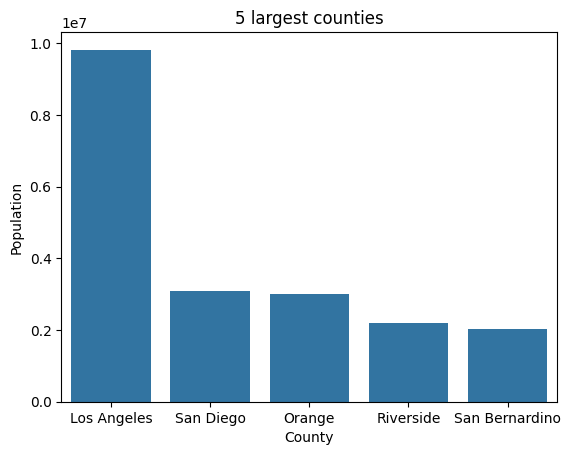

In [11]:
top_population = counties.agg({"TotalPopulation": "sum"}).nlargest(5, columns="TotalPopulation")
ax = sns.barplot(x="CountyName", y="TotalPopulation", data=top_population)
ax.set(xlabel="County", ylabel="Population", title="5 largest counties")

6 Highest Poverty Rates by County (mean aggregate)

[Text(0.5, 0, 'County'),
 Text(0, 0.5, 'Poverty Rate'),
 Text(0.5, 1.0, 'Top 6 Counties by Poverty Rate (mean)')]

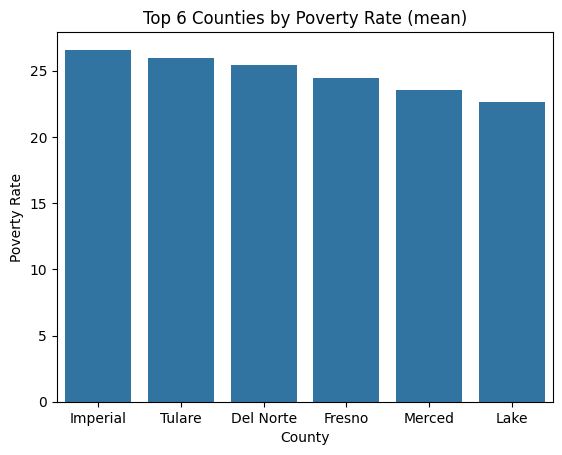

In [12]:
pov_rate = counties.agg({"PovertyRate": "mean"}).nlargest(6, columns="PovertyRate")
ax = sns.barplot(data=pov_rate, x="CountyName", y="PovertyRate")
ax.set(xlabel="County", ylabel="Poverty Rate", title="Top 6 Counties by Poverty Rate (mean)")

Population Weighted Poverty Rate

[Text(0.5, 0, 'County'),
 Text(0, 0.5, 'Poverty Rate'),
 Text(0.5, 1.0, 'Top 6 Counties by Poverty Rate (population weighted)')]

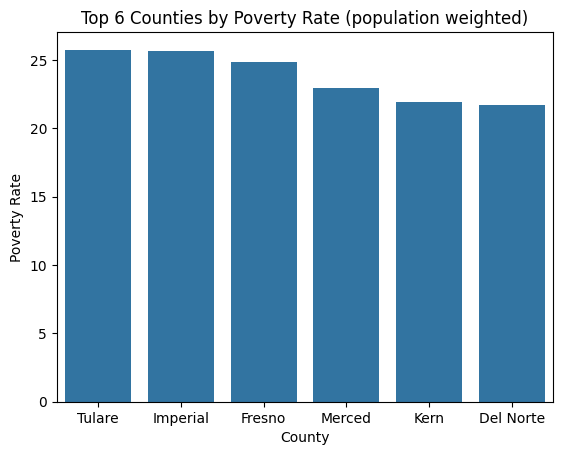

In [13]:
pov_rate = pop_weight(df, "PovertyRate").nlargest(6, columns="PovertyRate_weighted")
ax = sns.barplot(data=pov_rate, x="CountyName", y="PovertyRate_weighted")
ax.set(xlabel="County", ylabel="Poverty Rate", title="Top 6 Counties by Poverty Rate (population weighted)")

Low Income Tracts

[Text(0.5, 0, 'County'),
 Text(0, 0.5, '# Low Income Tracts'),
 Text(0.5, 1.0, 'Top 5 Counties by # Low Income Tracts')]

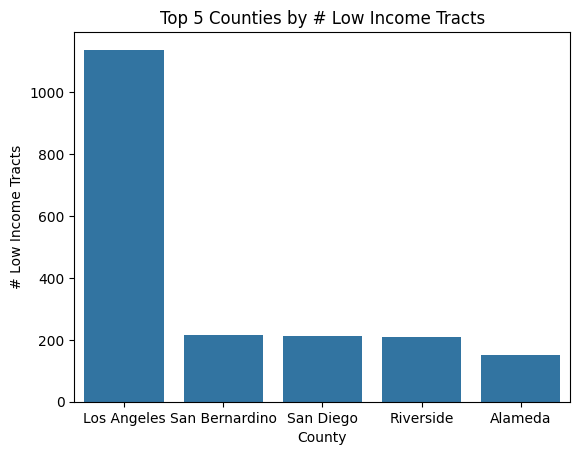

In [14]:
low_income = counties.agg({"LowIncomeTracts": "sum"}).nlargest(5, columns="LowIncomeTracts")
ax = sns.barplot(data=low_income, x="CountyName", y="LowIncomeTracts")
ax.set(xlabel="County", ylabel="# Low Income Tracts", title="Top 5 Counties by # Low Income Tracts")

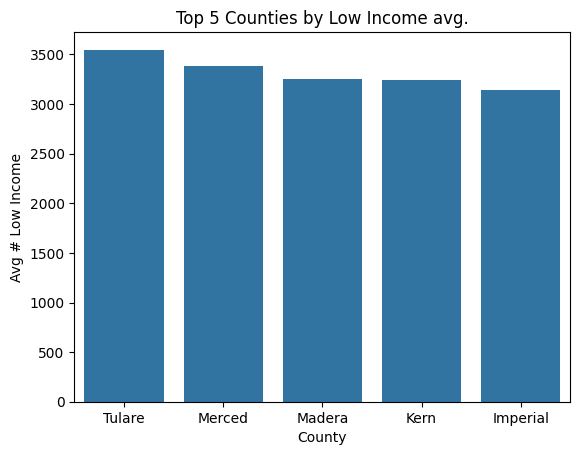

In [15]:
low_income = pop_weight(df, "TractLOWI").nlargest(5, columns="TractLOWI_weighted")
ax = sns.barplot(data=low_income, x="CountyName", y="TractLOWI_weighted")
ax.set(xlabel="County", ylabel="Avg # Low Income", title="Top 5 Counties by Low Income avg.")
plt.show()

Low Access Tracts

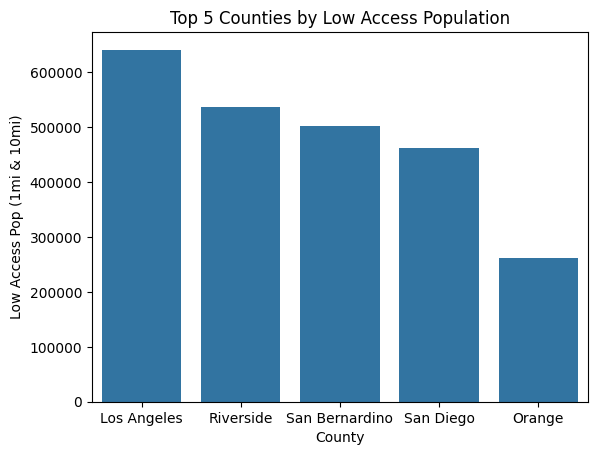

In [16]:
low_access_1and10 = counties.aggregate({"LAPOP1_10": "sum"}).nlargest(5, "LAPOP1_10")
ax = sns.barplot(data=low_access_1and10, x="CountyName", y="LAPOP1_10")
ax.set(xlabel="County", ylabel="Low Access Pop (1mi & 10mi)", title="Top 5 Counties by Low Access Population")
plt.show()

Create a df without confidence intervals

In [26]:
d_cols = []
for i in df.columns:
    if re.match(string=i, pattern=r'\S*(CI)$'):
        d_cols.append(i)
        
d_cols.append("Geolocation")
d_cols.append("GEOID")

In [27]:
no_ci = df.drop(columns=d_cols)

In [28]:
df.columns

Index(['CountyName', 'GEOID', 'TotalPopulation', 'ACCESS2_CrudePrev',
       'ACCESS2_Crude95CI', 'ARTHRITIS_CrudePrev', 'ARTHRITIS_Crude95CI',
       'BINGE_CrudePrev', 'BINGE_Crude95CI', 'BPHIGH_CrudePrev',
       'BPHIGH_Crude95CI', 'BPMED_CrudePrev', 'BPMED_Crude95CI',
       'CANCER_CrudePrev', 'CANCER_Crude95CI', 'CASTHMA_CrudePrev',
       'CASTHMA_Crude95CI', 'CERVICAL_CrudePrev', 'CERVICAL_Crude95CI',
       'CHD_CrudePrev', 'CHD_Crude95CI', 'CHECKUP_CrudePrev',
       'CHECKUP_Crude95CI', 'CHOLSCREEN_CrudePrev', 'CHOLSCREEN_Crude95CI',
       'COLON_SCREEN_CrudePrev', 'COLON_SCREEN_Crude95CI', 'COPD_CrudePrev',
       'COPD_Crude95CI', 'COREM_CrudePrev', 'COREM_Crude95CI',
       'COREW_CrudePrev', 'COREW_Crude95CI', 'CSMOKING_CrudePrev',
       'CSMOKING_Crude95CI', 'DENTAL_CrudePrev', 'DENTAL_Crude95CI',
       'DEPRESSION_CrudePrev', 'DEPRESSION_Crude95CI', 'DIABETES_CrudePrev',
       'DIABETES_Crude95CI', 'GHLTH_CrudePrev', 'GHLTH_Crude95CI',
       'HIGHCHOL_CrudePrev',

In [30]:
"CountyName" in no_ci.columns

True

County corresponding to the highest value in each column

In [31]:
for i in no_ci.columns.to_list():
    print(f"Highest {i}: {no_ci.loc[no_ci[i].idxmax(), :]["CountyName"]}")

Highest CountyName: Yuba
Highest TotalPopulation: San Diego
Highest ACCESS2_CrudePrev: Los Angeles
Highest ARTHRITIS_CrudePrev: Riverside
Highest BINGE_CrudePrev: Monterey
Highest BPHIGH_CrudePrev: Riverside
Highest BPMED_CrudePrev: Orange
Highest CANCER_CrudePrev: Contra Costa
Highest CASTHMA_CrudePrev: San Francisco
Highest CERVICAL_CrudePrev: Monterey
Highest CHD_CrudePrev: Los Angeles
Highest CHECKUP_CrudePrev: Contra Costa
Highest CHOLSCREEN_CrudePrev: Contra Costa
Highest COLON_SCREEN_CrudePrev: Contra Costa
Highest COPD_CrudePrev: Los Angeles
Highest COREM_CrudePrev: Marin
Highest COREW_CrudePrev: Santa Clara
Highest CSMOKING_CrudePrev: Imperial
Highest DENTAL_CrudePrev: Orange
Highest DEPRESSION_CrudePrev: San Luis Obispo
Highest DIABETES_CrudePrev: Los Angeles
Highest GHLTH_CrudePrev: Imperial
Highest HIGHCHOL_CrudePrev: Riverside
Highest KIDNEY_CrudePrev: Los Angeles
Highest LPA_CrudePrev: Imperial
Highest MAMMOUSE_CrudePrev: Los Angeles
Highest MHLTH_CrudePrev: San Luis Obis